# Demo MCMC in Martini

In [1]:
import martini.distributions as dist
import martini.mcmc as mcmc

import numpy as np
import matplotlib.pyplot as plt
import corner
from scipy.stats import norm, cauchy

## One-dimensional MCMC

Sample a normal distribution with a Cauchy proposal.

In [ ]:
# use Cauchy proposal distribution
proposal = dist.Cauchy(x0=1., gamma=3.)

# normal target distribution
target_mean = 1.5
target_std = 2.0
def target_lnpdf(x):
    return -0.5 * np.sum((x - target_mean)**2) / target_std**2

# run MCMC
mh_mcmc = mcmc.MetropolisHastings(target_lnpdf, proposal)
mh_mcmc.run(100_000)
print(f'acceptance rate: {mh_mcmc.acceptance_rate}')

[-2.26428637]
acceptance rate: 0.5451554515545155


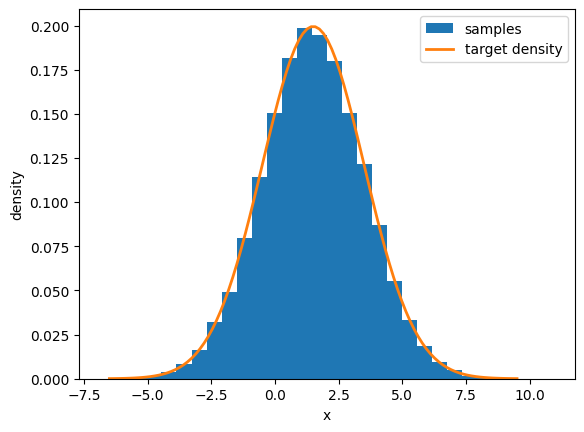

In [3]:
# plot recovered distribution
xs = np.linspace(target_mean - 4 * target_std, target_mean + 4 * target_std, 100)
plt.hist(mh_mcmc.samples, density=True, bins=30, label='samples')
plt.plot(xs, norm.pdf(xs, loc=target_mean, scale=target_std), color='C1', lw=2, label='target density')
plt.xlabel('x')
plt.ylabel('density')
plt.legend()
plt.show()

## Multi-dimensional MCMC

Sample a multivariate normal distribution with another multivariate normal.

In [14]:
# proposal distribution
ndim = 5
proposal_mean = np.random.randn(ndim)
proposal_cov = (lambda rand: rand @ rand.T + np.eye(ndim))(np.random.randn(ndim, ndim))
proposal = dist.Gaussian(proposal_mean, proposal_cov)


# target distribution
target_mean = proposal_mean + 0.3 * np.random.randn(ndim)
target_cov = 0.5 * proposal_cov
target_covinv = np.linalg.inv(target_cov)
def target_lnpdf(x):
    z = x - target_mean
    return -0.5 * z.T @ target_covinv @ z

# run MCMC
mh_mcmc = mcmc.MetropolisHastings(target_lnpdf, proposal)
mh_mcmc.run(100_000)
print(f'acceptance rate: {mh_mcmc.acceptance_rate}')

acceptance rate: 0.3962739627396274


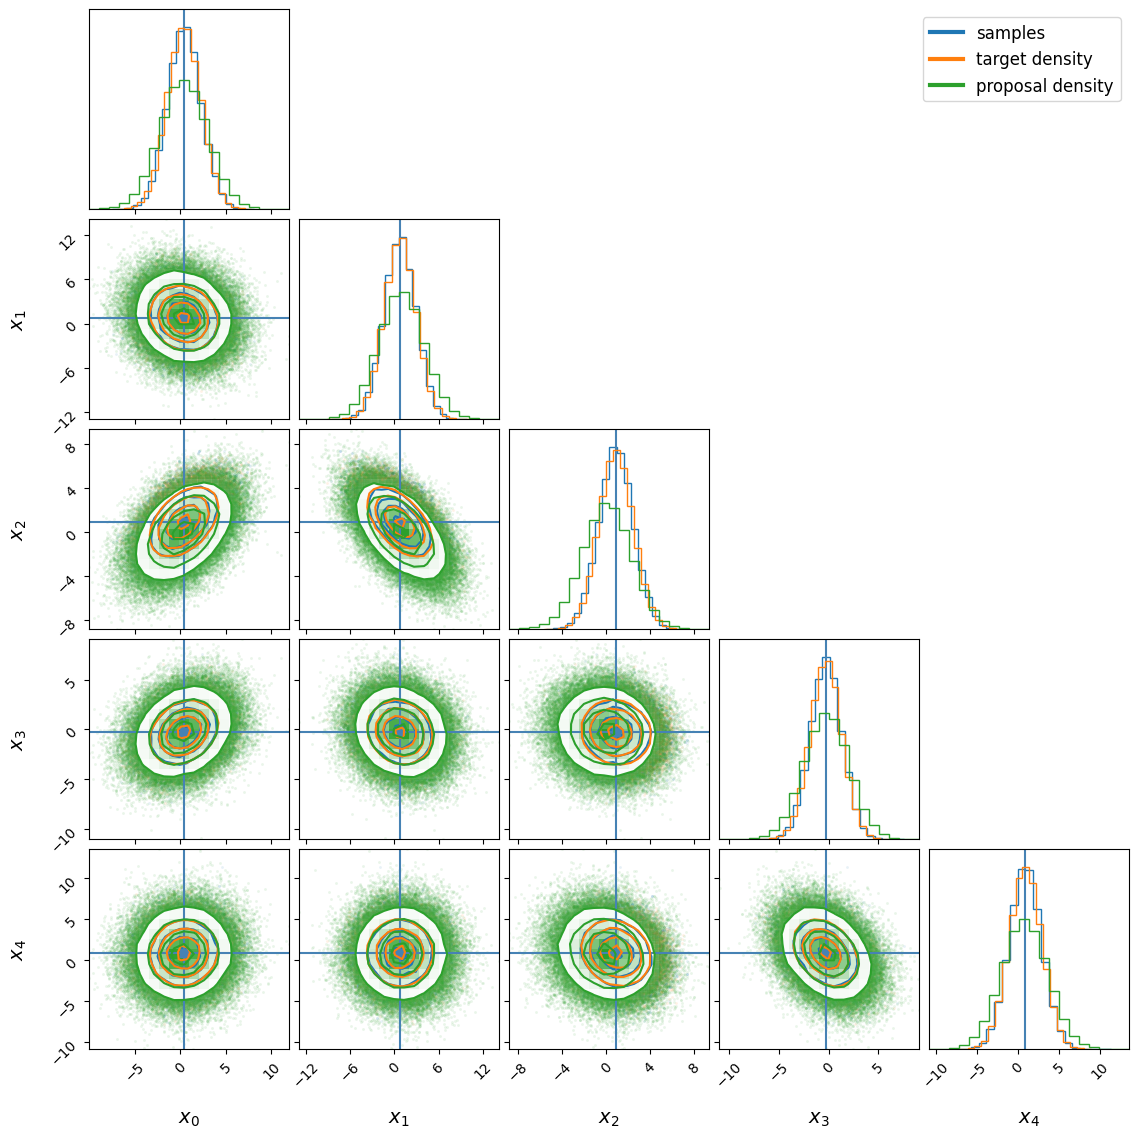

In [18]:
# show recovered distribution
fig = corner.corner(data=mh_mcmc.samples,
                    labels=[rf'$x_{{{i}}}$' for i in range(ndim)],
                    truths=target_mean,
                    label_kwargs={'fontsize': 14},
                    hist_kwargs={'density': True},
                    color='C0')
_ = corner.corner(data=np.random.multivariate_normal(target_mean,
                                                     target_cov,
                                                     size=100_000),
                  fig=fig,
                  hist_kwargs={'density': True},
                  color='C1')
_ = corner.corner(data=np.random.multivariate_normal(proposal_mean,
                                                     proposal_cov,
                                                     size=100_000),
                  fig=fig,
                  hist_kwargs={'density': True},
                  color='C2')
axes = np.array(fig.axes).reshape((ndim, ndim))
axes[0, -1].plot([], [], color='C0', lw=3, label='samples')
axes[0, -1].plot([], [], color='C1', lw=3, label='target density')
axes[0, -1].plot([], [], color='C2', lw=3, label='proposal density')
_ = axes[0, -1].legend(loc='upper right', fontsize=12)